# LUCY — Prueba con Imágenes y Videos Reales
## RT-DETR + TrafficRiskNet sobre escenas reales de tráfico

Este notebook carga el modelo entrenado en el Notebook 1 y lo prueba sobre:
- Imágenes reales de la carpeta `test_images/`
- Videos reales de la carpeta `test_videos/`

**Pipeline:**
```
Imagen/Video → RT-DETR (detecciones reales) → TrafficRiskNet → SAFE/WARNING/CRITICAL
```

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from pathlib import Path
from collections import deque
import onnxruntime as ort

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

os.makedirs('output', exist_ok=True)

Device: cuda


## 1. Redefinir arquitectura y cargar pesos

In [2]:
# ── Constantes ────────────────────────────────────────────────────────────────
RISK_CLASSES   = ['SAFE', 'WARNING', 'CRITICAL']
RISK_COLORS_BGR = {
    'SAFE':     (0, 200, 0),
    'WARNING':  (0, 165, 255),
    'CRITICAL': (0, 0, 255),
}
N_RISK         = 3
N_COCO_CLASSES = 80
D_MODEL        = 64
MAX_OBJECTS    = 20
SEQ_LEN        = 15
GRU_HIDDEN     = 128
GRU_LAYERS     = 2

COCO_NAMES = {
    0:'person', 1:'bicycle', 2:'car', 3:'motorcycle',
    5:'bus', 7:'truck', 9:'traffic light', 11:'stop sign'
}
TRAFFIC_IDS = {0, 1, 2, 3, 5, 7, 9, 11}

print('Constantes OK')

Constantes OK


In [3]:
# ── Arquitectura (igual que Notebook 1) ───────────────────────────────────────
class ObjectTokenEmbedding(nn.Module):
    def __init__(self, n_classes=N_COCO_CLASSES, d_model=D_MODEL):
        super().__init__()
        self.class_emb = nn.Embedding(n_classes + 1, 16, padding_idx=n_classes)
        self.geo_proj  = nn.Linear(5, 32)
        self.out_proj  = nn.Linear(48, d_model)
        self.norm      = nn.LayerNorm(d_model)
    def forward(self, tokens):
        cls_ids  = tokens[..., 0].long().clamp(0, N_COCO_CLASSES)
        geo      = tokens[..., 1:]
        cls_feat = self.class_emb(cls_ids)
        geo_feat = F.relu(self.geo_proj(geo))
        return self.norm(self.out_proj(torch.cat([cls_feat, geo_feat], -1)))


class SpatialRiskTransformer(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=4, num_layers=3,
                 dim_ff=256, dropout=0.1, max_objects=MAX_OBJECTS, n_classes=N_RISK):
        super().__init__()
        self.d_model     = d_model
        self.max_objects = max_objects
        self.token_emb   = ObjectTokenEmbedding(d_model=d_model)
        self.cls_token   = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(dropout*2),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, n_classes))
    def forward(self, tokens, padding_mask=None, return_features=False):
        B   = tokens.shape[0]
        x   = self.token_emb(tokens)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        if padding_mask is not None:
            cls_mask     = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            padding_mask = torch.cat([cls_mask, padding_mask], dim=1)
        encoded = self.encoder(x, src_key_padding_mask=padding_mask)
        cls_out = encoded[:, 0, :]
        if return_features:
            return cls_out
        logits = self.classifier(cls_out)
        return {'logits': logits, 'probs': F.softmax(logits, -1), 'features': cls_out}


class GRUTemporalEncoder(nn.Module):
    def __init__(self, input_size=D_MODEL, hidden_size=GRU_HIDDEN,
                 num_layers=GRU_LAYERS, dropout=0.3, n_classes=N_RISK):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, n_classes))
    def forward(self, x):
        out, _ = self.gru(x)
        logits = self.classifier(out[:, -1, :])
        return {'logits': logits, 'probs': F.softmax(logits, -1)}


class TrafficRiskNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial  = SpatialRiskTransformer()
        self.temporal = GRUTemporalEncoder()
    def forward(self, tokens_seq, masks_seq):
        B, T, N, F = tokens_seq.shape
        feats_flat  = self.spatial(tokens_seq.view(B*T, N, F),
                                   masks_seq.view(B*T, N), return_features=True)
        return self.temporal(feats_flat.view(B, T, D_MODEL))


# ── Cargar pesos ──────────────────────────────────────────────────────────────
model = TrafficRiskNet().to(DEVICE)
weights_path = 'models/traffic_risk_best.pth'
assert os.path.exists(weights_path), f'No se encontró {weights_path} — corre primero el Notebook 1'
model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
model.eval()
print('TrafficRiskNet cargado OK')

TrafficRiskNet cargado OK


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10420\2947373981.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


## 2. Cargar RT-DETR

In [4]:
class RTDetrDetector:
    """Wrapper del detector RT-DETR ONNX para clases de tráfico."""
    def __init__(self, model_path='rtdetr-l.onnx', conf=0.35):
        assert os.path.exists(model_path), f'No se encontró {model_path}'
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
        self.session    = ort.InferenceSession(model_path, providers=providers)
        self.input_name = self.session.get_inputs()[0].name
        _, _, self.in_h, self.in_w = self.session.get_inputs()[0].shape
        self.conf       = conf
        print(f'RT-DETR listo | Input: {self.in_w}x{self.in_h} | Backend: {self.session.get_providers()}')

    def preprocess(self, image):
        orig_h, orig_w = image.shape[:2]
        scale  = min(self.in_w / orig_w, self.in_h / orig_h)
        new_w, new_h = int(orig_w * scale), int(orig_h * scale)
        resized = cv2.resize(image, (new_w, new_h))
        canvas  = np.full((self.in_h, self.in_w, 3), 114, dtype=np.uint8)
        canvas[:new_h, :new_w] = resized
        img = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        return np.expand_dims(img.transpose(2, 0, 1), 0), scale, (orig_h, orig_w)

    def detect(self, image):
        inp, scale, (orig_h, orig_w) = self.preprocess(image)
        preds = self.session.run(None, {self.input_name: inp})[0][0]  # (300, 84)
        boxes, class_scores = preds[:, :4], preds[:, 4:]
        class_ids = np.argmax(class_scores, axis=1)
        scores    = class_scores[np.arange(len(class_ids)), class_ids]
        detections = []
        for i in range(len(preds)):
            if scores[i] < self.conf or int(class_ids[i]) not in TRAFFIC_IDS:
                continue
            xc, yc, w, h = boxes[i]
            xc *= self.in_w; yc *= self.in_h
            w  *= self.in_w; h  *= self.in_h
            x1 = max(0, int((xc - w/2) / scale))
            y1 = max(0, int((yc - h/2) / scale))
            x2 = min(orig_w-1, int((xc + w/2) / scale))
            y2 = min(orig_h-1, int((yc + h/2) / scale))
            detections.append({
                'bbox':       [x1, y1, x2, y2],
                'confidence': round(float(scores[i]), 3),
                'class_id':   int(class_ids[i]),
                'class_name': COCO_NAMES.get(int(class_ids[i]), '?'),
            })
        return detections


detector = RTDetrDetector('rtdetr-l.onnx', conf=0.35)

RT-DETR listo | Input: 640x640 | Backend: ['CPUExecutionProvider']


In [5]:
# ── Traffic Light State Detection (HSV) ─────────────────────────────────────
TL_COLORS_BGR = {
    'RED':     (0,   0,   255),
    'YELLOW':  (0,   215, 255),
    'GREEN':   (0,   200, 0  ),
    'UNKNOWN': (128, 128, 128),
}

def detect_tl_state(image, bbox):
    """Crop TL bbox, split vertically into 3 thirds, return dominant color."""
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(image.shape[1]-1, x2); y2 = min(image.shape[0]-1, y2)
    crop = image[y1:y2, x1:x2]
    if crop.size == 0 or crop.shape[0] < 6 or crop.shape[1] < 3:
        return 'UNKNOWN'
    hsv   = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    third = max(1, crop.shape[0] // 3)
    top   = hsv[:third]
    mid   = hsv[third:2*third]
    bot   = hsv[2*third:]
    MIN_PX = 5
    def count_red(h):
        m1 = cv2.inRange(h, (0,  100, 100), (10, 255, 255))
        m2 = cv2.inRange(h, (160,100, 100), (180,255, 255))
        return int(cv2.countNonZero(m1) + cv2.countNonZero(m2))
    def count_yellow(h):
        return int(cv2.countNonZero(cv2.inRange(h, (18, 100, 100), (35, 255, 255))))
    def count_green(h):
        return int(cv2.countNonZero(cv2.inRange(h, (40, 80,  80 ), (90, 255, 255))))
    scores = {
        'RED':    count_red(top),
        'YELLOW': count_yellow(mid),
        'GREEN':  count_green(bot),
    }
    best = max(scores, key=scores.get)
    return best if scores[best] >= MIN_PX else 'UNKNOWN'


def enrich_detections(image, detections):
    """Add tl_state key to every detection (None for non-TL objects)."""
    for det in detections:
        det['tl_state'] = detect_tl_state(image, det['bbox']) if det['class_id'] == 9 else None
    return detections


def apply_tl_context(result, detections):
    """Upgrade SAFE -> WARNING when RED light + person are both present."""
    if result is None:
        return result, False
    has_red = any(d.get('tl_state') == 'RED' for d in detections)
    has_ped = any(d['class_id'] == 0         for d in detections)
    if has_red and has_ped and result['risk_level'] == 'SAFE':
        result = dict(result)
        result['risk_level'] = 'WARNING'
        return result, True
    return result, False


print('TL detector OK')


TL detector OK


In [6]:
# ── Demo: traffic light color detection ──────────────────────────────────────
# Tries every image in test_images/. If no TL is found by the detector,
# falls back to synthetic HSV patches to prove the logic works.

def _show_tl_crops(image, tl_dets, ax_row, title_prefix=''):
    """Draw each TL crop with its detected state in a row of axes."""
    for col_i, det in enumerate(tl_dets):
        if col_i >= len(ax_row):
            break
        x1,y1,x2,y2 = [max(0,int(v)) for v in det['bbox']]
        crop = image[y1:y2, x1:x2]
        state = det.get('tl_state','?')
        circle_col = {'RED':(1,0,0),'YELLOW':(1,0.85,0),'GREEN':(0,0.78,0)}.get(state,(0.5,0.5,0.5))
        ax = ax_row[col_i]
        if crop.size > 0:
            ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        else:
            ax.set_facecolor('black')
        circle = plt.Circle((0.5,0.5), 0.35, color=circle_col, transform=ax.transAxes, zorder=5)
        ax.add_patch(circle)
        ax.set_title(f'{title_prefix}TL #{col_i+1}\n{state}',
                     color=circle_col if state != 'UNKNOWN' else 'gray',
                     fontweight='bold', fontsize=9)
        ax.axis('off')

# ── 1. Try real images ────────────────────────────────────────────────────────
all_tl_found = []   # list of (img_bgr, det)
for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue
    dets = detector.detect(img)
    dets = enrich_detections(img, dets)
    tl_dets = [d for d in dets if d['class_id'] == 9]
    for d in tl_dets:
        all_tl_found.append((img, d, Path(img_path).name))

print(f'Traffic lights found in real images: {len(all_tl_found)}')

# ── 2. Synthetic fallback: solid-color patches ────────────────────────────────
def _make_synth_tl(dominant_color, size=(90,30)):
    """Create a BGR image that looks like a traffic light (3 circles)."""
    h, w = size[0], size[1]
    img  = np.zeros((h, w, 3), dtype=np.uint8) + 30
    r = w // 2
    cx = w // 2
    positions = [('RED',h//6), ('YELLOW',h//2), ('GREEN',5*h//6)]
    cols_bgr  = {'RED':(0,0,220),'YELLOW':(0,200,220),'GREEN':(0,200,50)}
    for color, cy in positions:
        c = cols_bgr[color] if color == dominant_color else (40,40,40)
        cv2.circle(img, (cx, cy), r-3, c, -1)
    return img

synth_cases = [
    ('RED',    _make_synth_tl('RED')),
    ('YELLOW', _make_synth_tl('YELLOW')),
    ('GREEN',  _make_synth_tl('GREEN')),
]

# Verify synthetic: wrap each as a fake detection
synth_results = []
for expected, patch in synth_cases:
    h_p, w_p = patch.shape[:2]
    fake_det = {'class_id':9, 'bbox':[0,0,w_p,h_p], 'confidence':1.0,
                'class_name':'traffic light', 'tl_state':None}
    fake_det['tl_state'] = detect_tl_state(patch, fake_det['bbox'])
    synth_results.append((expected, fake_det['tl_state'], patch))
    ok = '  OK' if expected == fake_det['tl_state'] else '  MISMATCH'
    print(f'  Synthetic {expected:6s} -> detected: {fake_det["tl_state"]}{ok}')

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n_real   = min(len(all_tl_found), 5)
n_synth  = 3
n_cols   = max(n_real, n_synth, 1)

fig, axes = plt.subplots(2, n_cols, figsize=(3.5*n_cols, 7))
# Ensure axes is always 2D
if n_cols == 1:
    axes = [[axes[0]], [axes[1]]]

# Row 0: real TL crops (or blank if none)
for col in range(n_cols):
    axes[0][col].axis('off')
if all_tl_found:
    for col, (img_bgr, det, fname) in enumerate(all_tl_found[:n_cols]):
        x1,y1,x2,y2 = [max(0,int(v)) for v in det['bbox']]
        crop = img_bgr[y1:y2, x1:x2]
        state = det.get('tl_state','?')
        c_mpl = {'RED':(1,0,0),'YELLOW':(1,0.85,0),'GREEN':(0,0.78,0)}.get(state,(0.5,0.5,0.5))
        ax = axes[0][col]
        if crop.size > 0:
            ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        circle = plt.Circle((0.9,0.9), 0.08, color=c_mpl, transform=ax.transAxes, zorder=5)
        ax.add_patch(circle)
        ax.set_title(f'REAL: {fname}\ndetected: {state}',
                     color=c_mpl, fontweight='bold', fontsize=9)
        ax.axis('off')
else:
    axes[0][0].text(0.5, 0.5, 'No TL detected\nin test_images',
                    ha='center', va='center', fontsize=11, color='gray',
                    transform=axes[0][0].transAxes)
    axes[0][0].set_facecolor('#111')

# Row 1: synthetic validation
for col in range(n_cols):
    axes[1][col].axis('off')
for col, (expected, detected, patch) in enumerate(synth_results):
    ax   = axes[1][col]
    c_mpl = {'RED':(1,0,0),'YELLOW':(1,0.85,0),'GREEN':(0,0.78,0)}.get(detected,(0.5,0.5,0.5))
    ok   = detected == expected
    ax.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    ax.set_title(f'SYNTH expected: {expected}\ndetected: {detected}  {"OK" if ok else "FAIL"}',
                 color=c_mpl if ok else 'red', fontweight='bold', fontsize=9)
    ax.axis('off')

fig.text(0.5, 0.97, 'LUCY -- Traffic Light State Detection Demo',
         ha='center', fontsize=13, fontweight='bold')
fig.text(0.5, 0.52, 'Row 1: Real detections', ha='center', fontsize=10, color='#333')
fig.text(0.5, 0.02, 'Row 2: Synthetic validation (HSV logic)', ha='center', fontsize=10, color='#333')

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig('output/tl_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/tl_demo.png')


NameError: name 'image_paths' is not defined

## 3. Utilidades — predicción y visualización

In [7]:
def detections_to_tokens(detections, img_w, img_h, max_objects=MAX_OBJECTS):
    rows = []
    for det in detections[:max_objects]:
        b  = det['bbox']
        cx = (b[0]+b[2])/2/img_w
        cy = (b[1]+b[3])/2/img_h
        w  = (b[2]-b[0])/img_w
        h  = (b[3]-b[1])/img_h
        rows.append([float(det['class_id']), cx, cy, w, h, float(det['confidence'])])
    n    = len(rows)
    rows += [[float(N_COCO_CLASSES), 0, 0, 0, 0, 0]] * (max_objects - n)
    return (torch.tensor(rows, dtype=torch.float32),
            torch.tensor([False]*n + [True]*(max_objects-n), dtype=torch.bool))


class SequenceBuffer:
    """Sliding window buffer that feeds the GRU."""
    def __init__(self, seq_len=SEQ_LEN):
        self.buffer  = deque(maxlen=seq_len)
        self.seq_len = seq_len

    def push(self, detections, img_w, img_h):
        tokens, mask = detections_to_tokens(detections, img_w, img_h)
        self.buffer.append((tokens, mask))

    @property
    def ready(self):
        return len(self.buffer) == self.seq_len

    def predict(self):
        if not self.ready:
            return None
        tokens_seq = torch.stack([b[0] for b in self.buffer]).unsqueeze(0).to(DEVICE)
        masks_seq  = torch.stack([b[1] for b in self.buffer]).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = model(tokens_seq, masks_seq)
        idx = out['probs'].argmax(-1).item()
        return {
            'risk_level': RISK_CLASSES[idx],
            'confidence': float(out['probs'][0, idx]),
            'all_probs':  {RISK_CLASSES[i]: round(float(out['probs'][0, i]), 3) for i in range(N_RISK)},
            'frames_in':  len(self.buffer),
        }


def draw_frame(image, detections, result, tl_override=False):
    """Draw bboxes + risk banner + TL state circles."""
    out   = image.copy()
    h, w  = out.shape[:2]
    level = result['risk_level'] if result else 'SAFE'
    color = RISK_COLORS_BGR.get(level, (0, 200, 0))

    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        c     = (0, 0, 255) if det['class_id'] == 0 else color
        label = f"{det['class_name']} {det['confidence']:.2f}"

        # Colored circle above TL bbox
        if det['class_id'] == 9 and det.get('tl_state'):
            tl_col = TL_COLORS_BGR.get(det['tl_state'], (128, 128, 128))
            cx_tl  = (x1 + x2) // 2
            cy_tl  = max(y1 - 12, 12)
            cv2.circle(out, (cx_tl, cy_tl), 10, tl_col, -1)
            cv2.circle(out, (cx_tl, cy_tl), 10, (255, 255, 255), 1)
            label = f"TL:{det['tl_state']} {det['confidence']:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), c, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, y1-th-6), (x1+tw+4, y1), c, -1)
        cv2.putText(out, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    # Top banner
    cv2.rectangle(out, (0, 0), (w, 55), color, -1)
    labels_es  = {'SAFE': 'SEGURO', 'WARNING': 'PRECAUCION', 'CRITICAL': 'PELIGRO'}
    conf_txt   = f"{result['confidence']*100:.0f}%" if result else '...'
    frames_txt = f"frames: {result['frames_in']}/{SEQ_LEN}" if result else 'warming...'
    banner_txt = f"LUCY: {labels_es.get(level, level)}  ({conf_txt})"
    if tl_override:
        banner_txt += '  [TL OVERRIDE]'
    cv2.putText(out, banner_txt,
                (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    probs_txt = '  |  '.join([f"{k}: {v:.2f}" for k, v in result['all_probs'].items()]) if result else ''
    cv2.putText(out, probs_txt + '  ' + frames_txt,
                (10, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    return out


print('Utils OK')


Utils OK


## 4. Prueba con imágenes estáticas

Para imágenes individuales usamos **solo el SpatialRiskTransformer** (no necesita secuencia).
El GRU requiere SEQ_LEN=15 frames — se activa en la prueba de video.

In [11]:
def predict_single_image(image, detector, model):
    """Spatial-only prediction for a single frame (no GRU needed)."""
    h, w   = image.shape[:2]
    dets   = detector.detect(image)
    dets   = enrich_detections(image, dets)
    tokens, mask = detections_to_tokens(dets, w, h)
    tokens = tokens.unsqueeze(0).to(DEVICE)
    mask   = mask.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model.spatial(tokens, mask)
    idx    = out['probs'].argmax(-1).item()
    result = {
        'risk_level': RISK_CLASSES[idx],
        'confidence': float(out['probs'][0, idx]),
        'all_probs':  {RISK_CLASSES[i]: round(float(out['probs'][0, i]), 3) for i in range(N_RISK)},
        'frames_in':  1,
    }
    result, tl_ovr = apply_tl_context(result, dets)
    return dets, result, tl_ovr


# Search for images
image_paths = sorted([
    str(p) for p in Path('test_images').glob('*')
    if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
])
print(f'Images found: {len(image_paths)}')
for p in image_paths:
    print(f'  {p}')


Images found: 11
  test_images\calle1.jpg
  test_images\calle2.jpg
  test_images\calle3.png
  test_images\calle3oscura.jpg
  test_images\prueba1.jpg
  test_images\prueba3.jpg
  test_images\prueuba2.jpg
  test_images\unreal.png
  test_images\unreal1.png
  test_images\unreal2.png
  test_images\unreal3.png


calle1.jpg                     -> WARNING  (43%) dets=3 tl_ovr=False
calle2.jpg                     -> CRITICAL (55%) dets=6 tl_ovr=False
calle3.png                     -> WARNING  (52%) dets=6 tl_ovr=False
calle3oscura.jpg               -> CRITICAL (65%) dets=1 tl_ovr=False
prueba1.jpg                    -> CRITICAL (51%) dets=16 tl_ovr=False
prueba3.jpg                    -> CRITICAL (59%) dets=1 tl_ovr=False
prueuba2.jpg                   -> CRITICAL (59%) dets=1 tl_ovr=False
unreal.png                     -> CRITICAL (66%) dets=3 tl_ovr=False
unreal1.png                    -> CRITICAL (62%) dets=9 tl_ovr=False
unreal2.png                    -> CRITICAL (47%) dets=19 tl_ovr=False
unreal3.png                    -> CRITICAL (50%) dets=17 tl_ovr=False


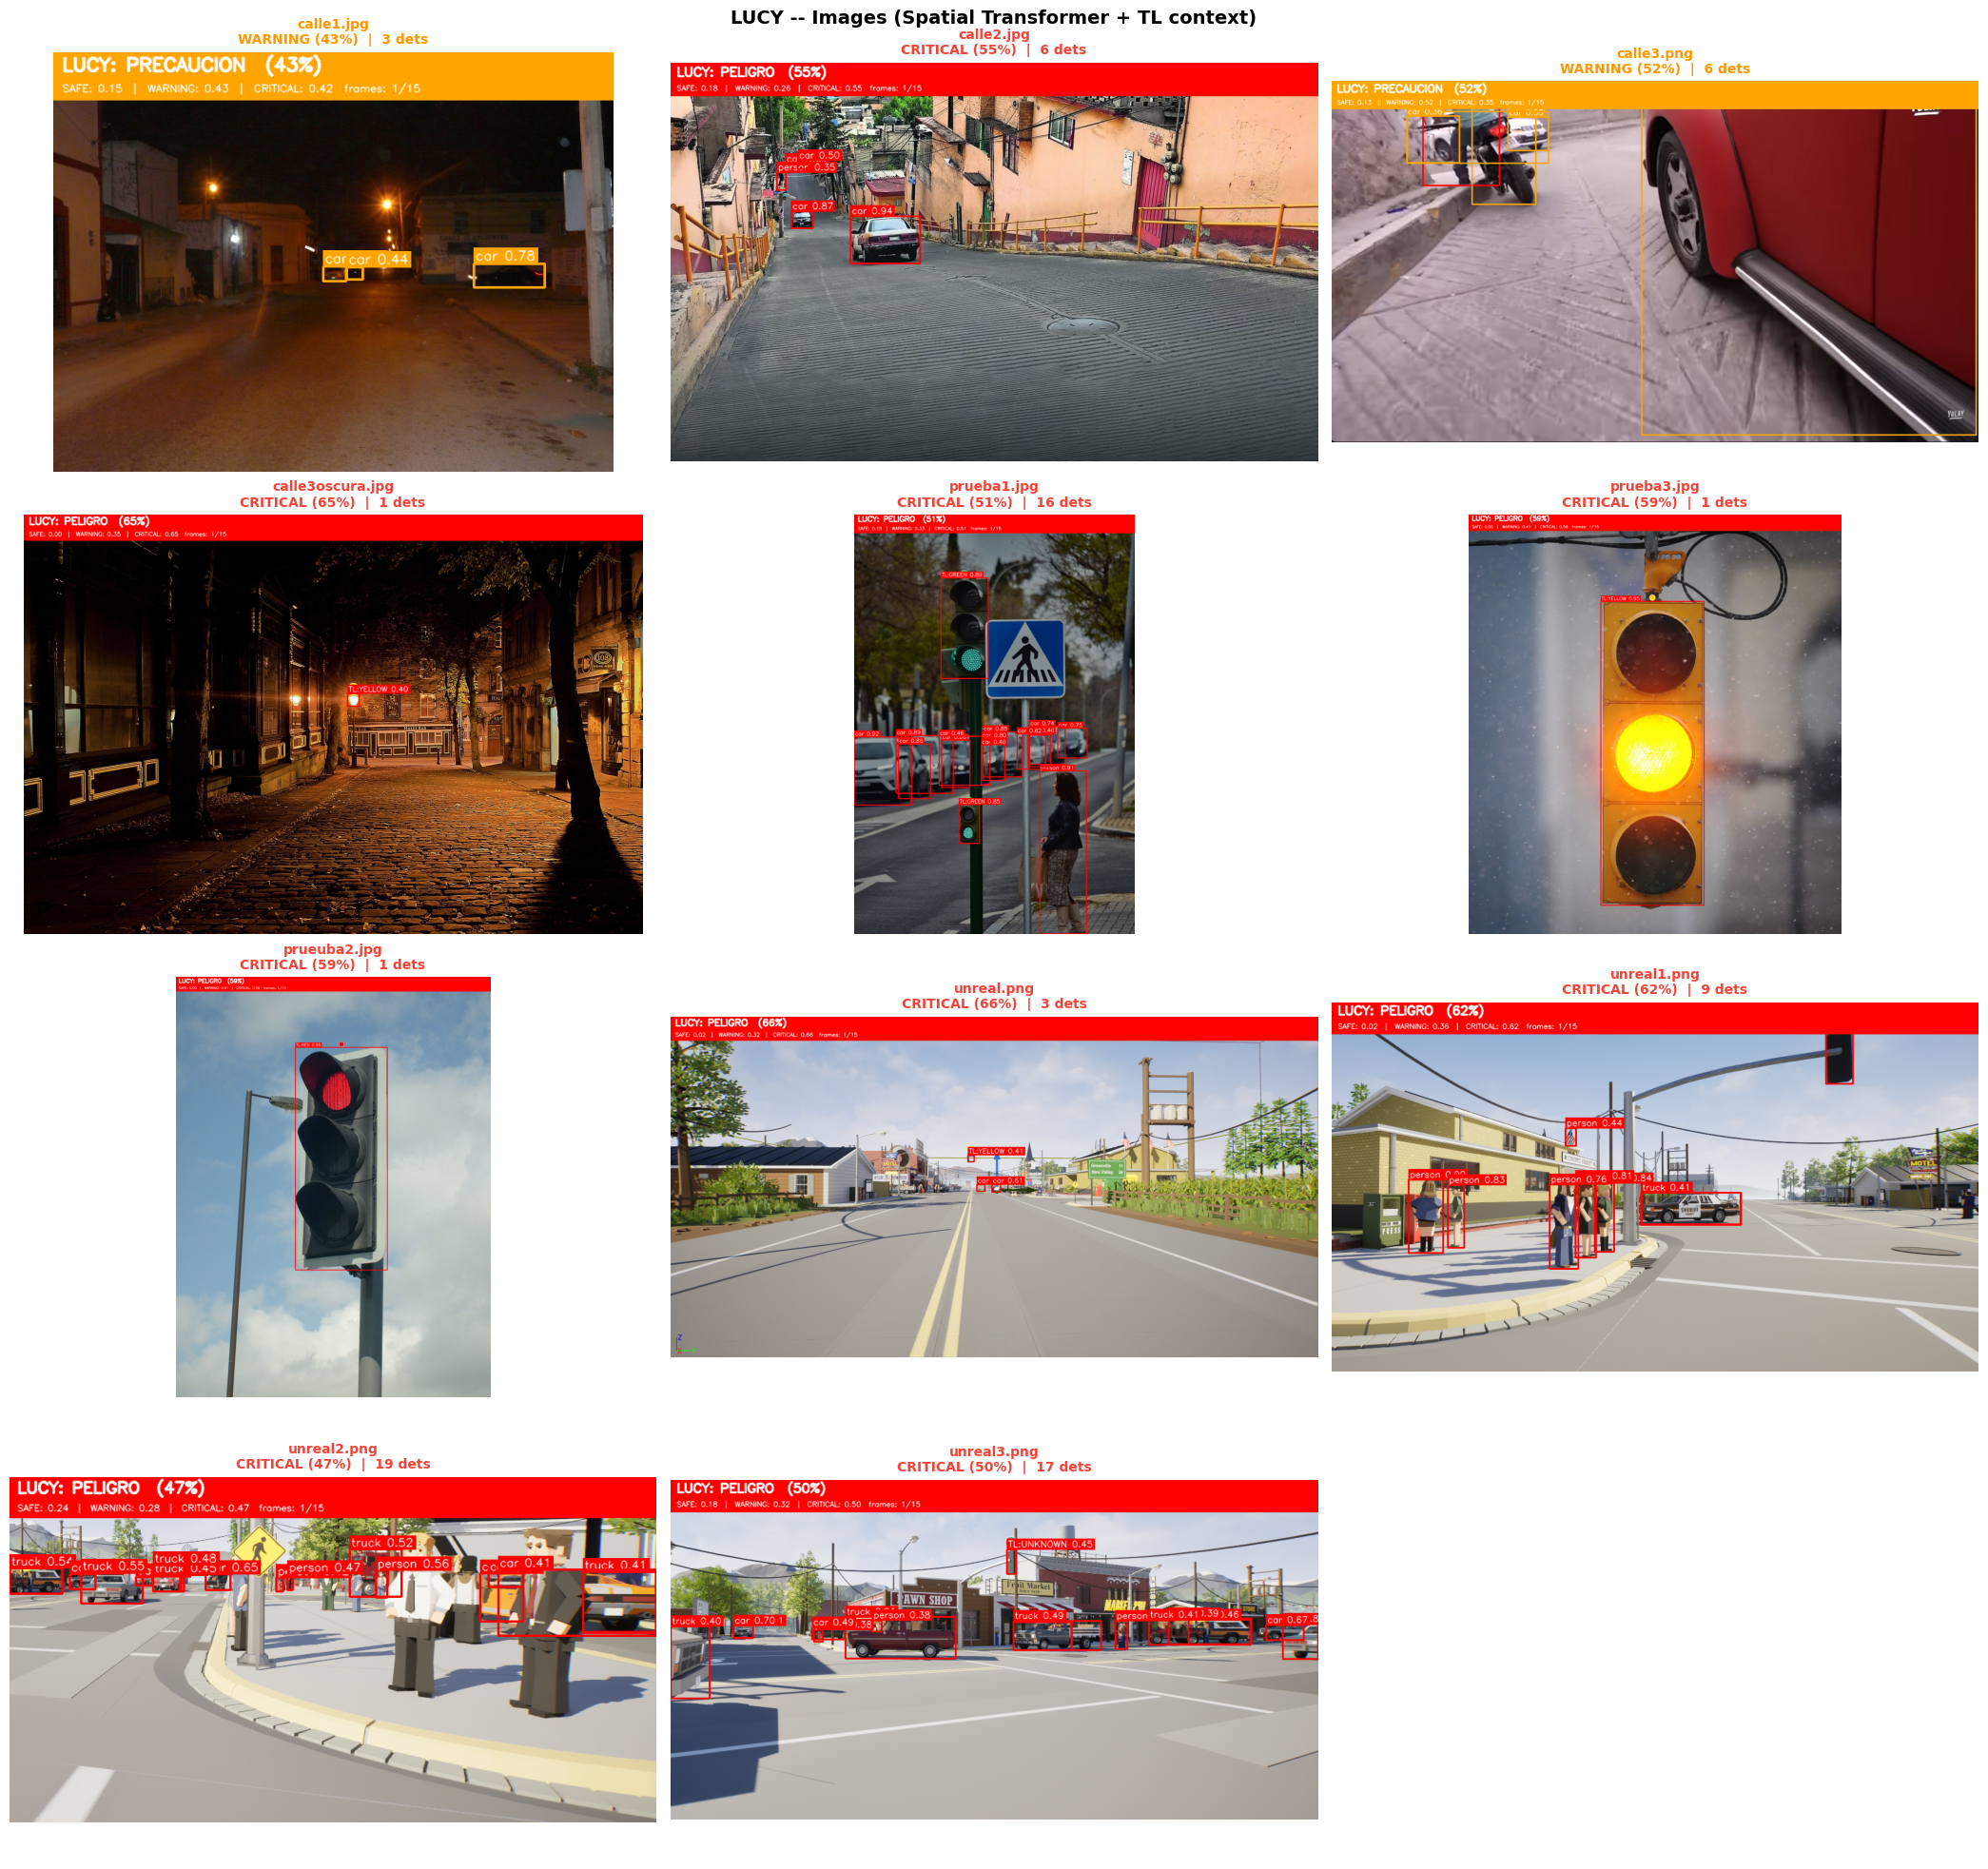


Saved: output/prueba_imagenes.png


In [12]:
if not image_paths:
    print('No images in test_images/ -- add some and re-run')
else:
    n_imgs = len(image_paths)
    cols   = min(n_imgs, 3)
    rows   = (n_imgs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))
    if n_imgs == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]

    COLORS_MPL = {'SAFE': '#4CAF50', 'WARNING': '#FF9800', 'CRITICAL': '#F44336'}

    for idx, img_path in enumerate(image_paths):
        row, col = divmod(idx, cols)
        ax = axes[row][col]

        img = cv2.imread(img_path)
        if img is None:
            ax.set_title(f'Could not read: {img_path}'); ax.axis('off'); continue

        dets, result, tl_ovr = predict_single_image(img, detector, model)
        annotated     = draw_frame(img, dets, result, tl_override=tl_ovr)
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        ax.imshow(annotated_rgb)
        level = result['risk_level']
        tl_tag = ' [TL]' if tl_ovr else ''
        ax.set_title(f"{Path(img_path).name}\n{level}{tl_tag} ({result['confidence']*100:.0f}%)  |  {len(dets)} dets",
                     color=COLORS_MPL[level], fontweight='bold', fontsize=10)
        ax.axis('off')
        print(f"{Path(img_path).name:30s} -> {level:8s} ({result['confidence']*100:.0f}%) dets={len(dets)} tl_ovr={tl_ovr}")

    for idx in range(n_imgs, rows * cols):
        row, col = divmod(idx, cols)
        axes[row][col].axis('off')

    plt.suptitle('LUCY -- Images (Spatial Transformer + TL context)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/prueba_imagenes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved: output/prueba_imagenes.png')


## 5. Prueba con video real
El GRU se activa aquí — necesita los 15 frames para dar su primera predicción.

In [ ]:
video_paths = sorted([
    str(p) for p in Path('test_videos').glob('*')
    if p.suffix.lower() in ('.mp4', '.avi', '.mov', '.mkv')
])
print(f'Videos encontrados: {len(video_paths)}')
for p in video_paths:
    print(f'  {p}')

Videos encontrados: 1
  test_videos\video1.mp4


In [ ]:
def process_video(video_path, max_frames=300, sample_every=2):
    """Process a video, return annotated frames + risk history."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'Could not open: {video_path}')
        return [], []

    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Video: {Path(video_path).name} | {w}x{h} | {fps:.0f}fps | {total} frames')

    buf          = SequenceBuffer(SEQ_LEN)
    annotated    = []
    risk_history = []
    last_result  = None
    last_tl_ovr  = False
    frame_idx    = 0

    while len(annotated) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        if frame_idx % sample_every != 0:
            continue

        dets  = detector.detect(frame)
        dets  = enrich_detections(frame, dets)
        buf.push(dets, w, h)

        result = buf.predict()
        if result:
            result, tl_ovr = apply_tl_context(result, dets)
            last_result    = result
            last_tl_ovr    = tl_ovr

        display_result = last_result if last_result else {
            'risk_level': 'SAFE', 'confidence': 0.0,
            'all_probs': {k: 0.0 for k in RISK_CLASSES},
            'frames_in': len(buf.buffer),
        }

        annotated.append(draw_frame(frame, dets, display_result, tl_override=last_tl_ovr))
        risk_history.append(display_result['risk_level'])

        if len(annotated) % 30 == 0:
            print(f'  Frame {len(annotated):4d} | dets={len(dets):2d} | {display_result["risk_level"]}'
                  + (' [TL]' if last_tl_ovr else ''))

    cap.release()
    print(f'Processed {len(annotated)} frames')
    return annotated, risk_history


print('Video processing function OK')


Video processing function OK


In [ ]:
if not video_paths:
    print('No hay videos en test_videos/ — agrega videos y vuelve a correr')
else:
    VIDEO_PATH = video_paths[0]   # Cambiar índice para probar otros videos
    print(f'Procesando: {VIDEO_PATH}')
    frames_out, risk_hist = process_video(VIDEO_PATH, max_frames=200, sample_every=2)

Procesando: test_videos\video1.mp4
Video: video1.mp4 | 576x1024 | 30fps | 339 frames
  Frame   30 | dets= 4 | CRITICAL
  Frame   60 | dets= 8 | CRITICAL
  Frame   90 | dets= 2 | CRITICAL
  Frame  120 | dets= 1 | CRITICAL
  Frame  150 | dets= 0 | SAFE
Processed 169 frames


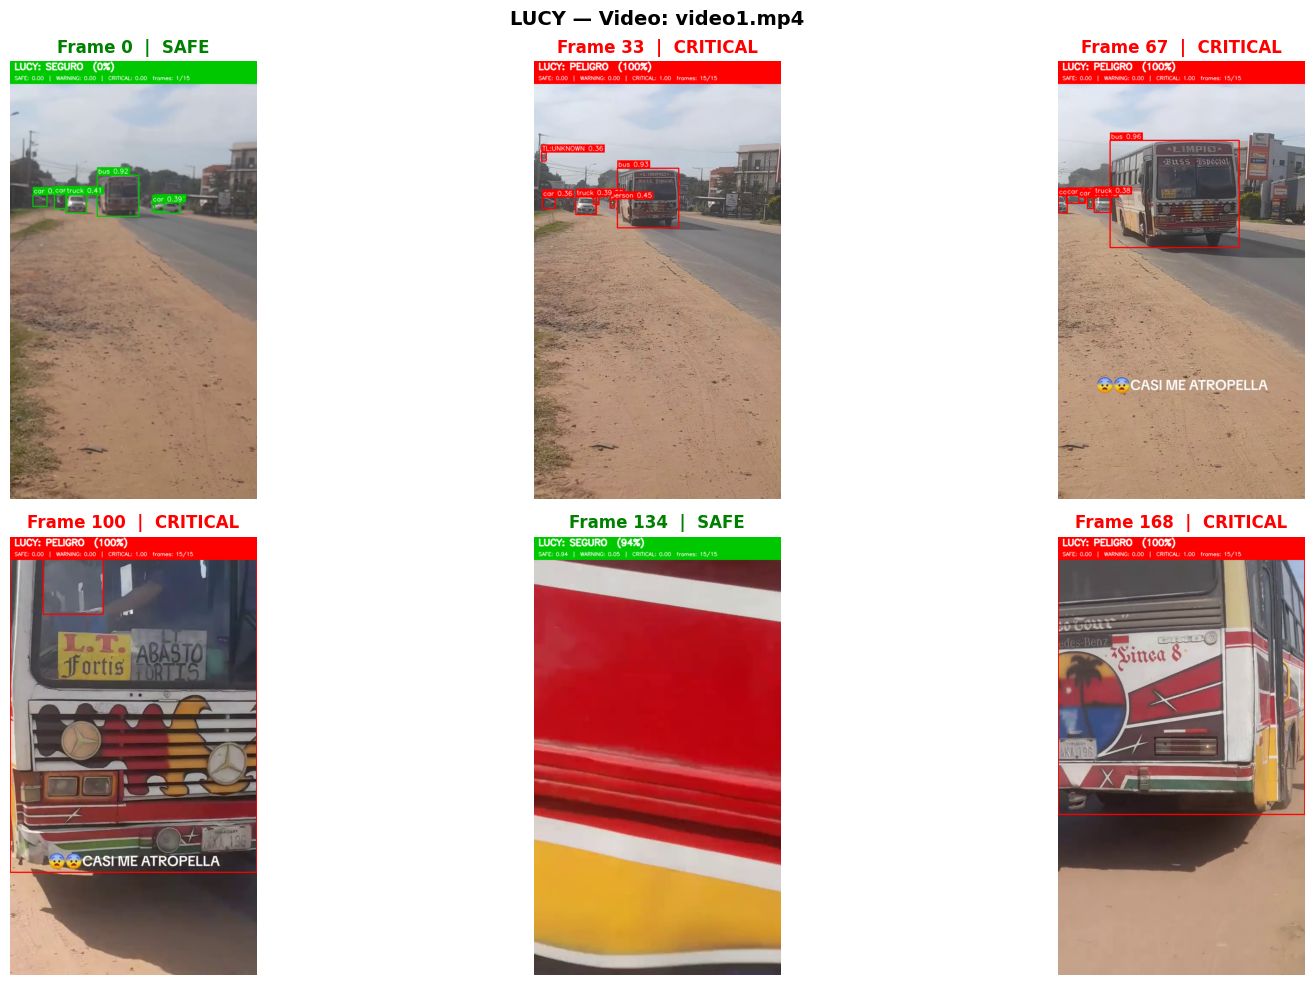

In [ ]:
# Mostrar muestra de frames anotados del video
if 'frames_out' in dir() and frames_out:
    sample_idx = np.linspace(0, len(frames_out)-1, 6, dtype=int)
    fig, axes  = plt.subplots(2, 3, figsize=(18, 10))

    for i, fidx in enumerate(sample_idx):
        ax  = axes[i//3][i%3]
        rgb = cv2.cvtColor(frames_out[fidx], cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        ax.set_title(f'Frame {fidx}  |  {risk_hist[fidx]}',
                     color={'SAFE':'green','WARNING':'orange','CRITICAL':'red'}.get(risk_hist[fidx],'gray'),
                     fontweight='bold')
        ax.axis('off')

    plt.suptitle(f'LUCY — Video: {Path(VIDEO_PATH).name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/prueba_video_frames.png', dpi=130, bbox_inches='tight')
    plt.show()

Distribución en 169 frames:
  SAFE      :   32 frames (18.9%)
  CRITICAL  :  127 frames (75.1%)


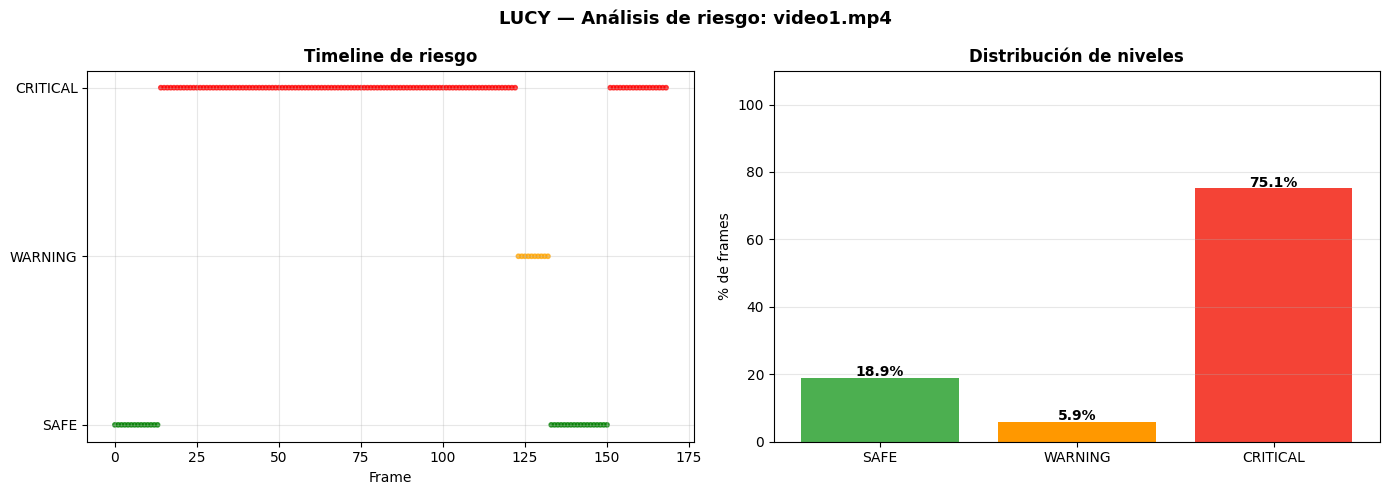

In [ ]:
# Distribución de niveles de riesgo a lo largo del video
if 'risk_hist' in dir() and risk_hist:
    from collections import Counter
    counts = Counter(risk_hist)
    total  = len(risk_hist)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Timeline
    numeric = {'SAFE': 0, 'WARNING': 1, 'CRITICAL': 2}
    colors_line = ['green' if r == 'SAFE' else 'orange' if r == 'WARNING' else 'red'
                   for r in risk_hist]
    axes[0].scatter(range(len(risk_hist)), [numeric[r] for r in risk_hist],
                    c=colors_line, s=10, alpha=0.7)
    axes[0].set_yticks([0, 1, 2])
    axes[0].set_yticklabels(RISK_CLASSES)
    axes[0].set_xlabel('Frame')
    axes[0].set_title('Timeline de riesgo', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Distribución
    bars = axes[1].bar(
        RISK_CLASSES,
        [counts.get(r, 0) / total * 100 for r in RISK_CLASSES],
        color=['#4CAF50', '#FF9800', '#F44336']
    )
    for bar, r in zip(bars, RISK_CLASSES):
        pct = counts.get(r, 0) / total * 100
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{pct:.1f}%', ha='center', fontweight='bold')
    axes[1].set_ylabel('% de frames')
    axes[1].set_title('Distribución de niveles', fontweight='bold')
    axes[1].set_ylim(0, 110)
    axes[1].grid(True, alpha=0.3, axis='y')

    print(f'Distribución en {total} frames:')
    for r in RISK_CLASSES:
        print(f'  {r:10s}: {counts.get(r,0):4d} frames ({counts.get(r,0)/total*100:.1f}%)')

    plt.suptitle(f'LUCY — Análisis de riesgo: {Path(VIDEO_PATH).name}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/prueba_video_distribucion.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Guardar video anotado (opcional)
if 'frames_out' in dir() and frames_out:
    out_path = f'output/lucy_{Path(VIDEO_PATH).stem}_anotado.mp4'
    h_out, w_out = frames_out[0].shape[:2]
    writer = cv2.VideoWriter(out_path,
                             cv2.VideoWriter_fourcc(*'mp4v'),
                             15, (w_out, h_out))
    for f in frames_out:
        writer.write(f)
    writer.release()
    print(f'Video anotado guardado en: {out_path}')

Video anotado guardado en: output/lucy_video1_anotado.mp4


## 6. Análisis de errores — ¿Dónde falla el modelo?
Esto nos dice qué datos reales necesitamos agregar para mejorar.

Transiciones detectadas: 4
  Frame   14: SAFE → CRITICAL
  Frame  123: CRITICAL → WARNING
  Frame  133: WARNING → SAFE
  Frame  151: SAFE → CRITICAL


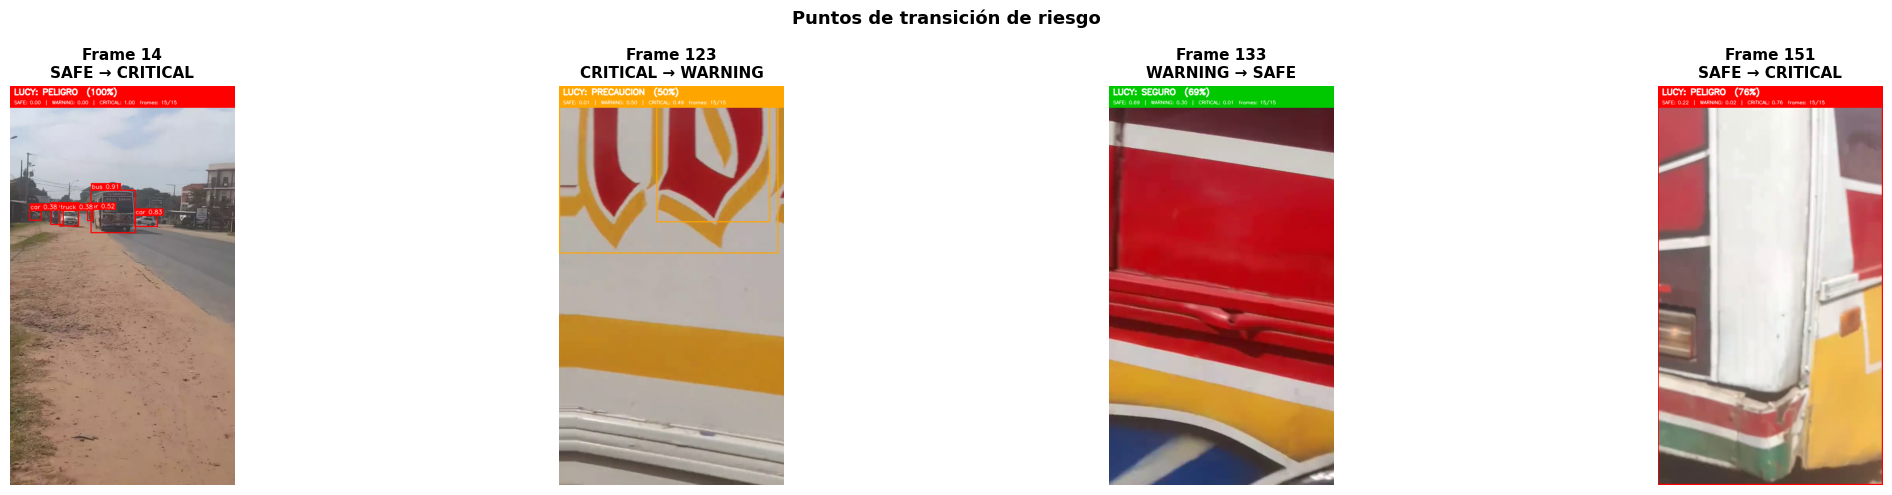

In [ ]:
# Mostrar frames donde el modelo cambia de nivel (puntos de transición)
if 'risk_hist' in dir() and len(risk_hist) > 1:
    transitions = []
    for i in range(1, len(risk_hist)):
        if risk_hist[i] != risk_hist[i-1]:
            transitions.append((i, risk_hist[i-1], risk_hist[i]))

    print(f'Transiciones detectadas: {len(transitions)}')
    for fidx, prev, curr in transitions[:10]:
        print(f'  Frame {fidx:4d}: {prev} → {curr}')

    if transitions and frames_out:
        n_show = min(len(transitions), 4)
        fig, axes = plt.subplots(1, n_show, figsize=(6*n_show, 5))
        if n_show == 1:
            axes = [axes]

        for i, (fidx, prev, curr) in enumerate(transitions[:n_show]):
            if fidx < len(frames_out):
                rgb = cv2.cvtColor(frames_out[fidx], cv2.COLOR_BGR2RGB)
                axes[i].imshow(rgb)
                axes[i].set_title(f'Frame {fidx}\n{prev} → {curr}',
                                  fontweight='bold', fontsize=11)
            axes[i].axis('off')

        plt.suptitle('Puntos de transición de riesgo', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('output/prueba_transiciones.png', dpi=130, bbox_inches='tight')
        plt.show()

## Conclusiones

Después de ver los resultados sobre datos reales, los posibles escenarios son:

| Resultado | Significado | Siguiente paso |
|---|---|---|
| Clasifica bien SAFE/CRITICAL pero falla en WARNING | Límites difusos en datos sintéticos | Agregar más escenas WARNING con variación real |
| Todo sale como SAFE | Las escenas reales son más vacías que las sintéticas | Bajar umbral de confianza del detector o ajustar generadores |
| Todo sale como CRITICAL | Los patrones de distancia son distintos en imágenes reales | Normalizar coordenadas, revisar escala | 
| Funciona bien en general | Los datos sintéticos generalizaron | Agregar datos JAAD para robustecer |

**El siguiente paso es el Notebook 3 — entrenamiento mixto con datos reales (JAAD).**